# DefectVision AI - Metal Surface Defect Detection
## Phase 1: Train YOLOv8 on NEU-DET Dataset

This notebook trains a YOLOv8 model to detect 6 types of metal surface defects:
- Crazing
- Inclusion
- Patches
- Pitted surface
- Rolled-in scale
- Scratches

**Supports: Google Colab, Kaggle, and local training.**

1. **Kaggle** (recommended): Use GPU P100 or T4x2 accelerator
2. **Colab**: Go to Runtime > Change runtime type > GPU (T4)
3. **Local**: Requires NVIDIA GPU with CUDA
4. Run all cells and download the trained weights at the end

## Step 1: Install Dependencies

In [4]:
import os, sys

def detect_environment():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE"):
        return "kaggle"
    try:
        import google.colab
        return "colab"
    except ImportError:
        pass
    return "local"

ENV = detect_environment()

if ENV in ("kaggle", "colab"):
    os.system("pip install ultralytics roboflow -q")
    print("Installed ultralytics + roboflow")
else:
    print("Local mode: using existing packages (run 'pip install ultralytics roboflow' if missing)")

Installed ultralytics + roboflow


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
fastai 2.8.4 requires fastcore<1.9,>=1.8.0, but you have fastcore 1.11.3 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, bu

## Step 2: Check GPU & Configure Training Parameters

In [6]:
import torch

import os, sys

def detect_environment():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE"):
        return "kaggle"
    try:
        import google.colab
        return "colab"
    except ImportError:
        pass
    return "local"

ENV = detect_environment()
print(f"Detected environment: {ENV.upper()}")

print(f"Environment:     {ENV.upper()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    GPU_NAME = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    VRAM_GB = getattr(props, 'total_memory', getattr(props, 'total_mem', 0)) / 1e9
    DEVICE = 0
    print(f"GPU:             {GPU_NAME}")
    print(f"VRAM:            {VRAM_GB:.1f} GB")
    print(f"CUDA version:    {torch.version.cuda}")

    if VRAM_GB >= 12:
        BATCH_SIZE = 16
        MODEL_SIZE = "yolov8s.pt"
    elif VRAM_GB >= 6:
        BATCH_SIZE = 12
        MODEL_SIZE = "yolov8s.pt"
    elif VRAM_GB >= 4:
        BATCH_SIZE = 8
        MODEL_SIZE = "yolov8n.pt"
    else:
        BATCH_SIZE = 4
        MODEL_SIZE = "yolov8n.pt"
else:
    GPU_NAME = "CPU"
    VRAM_GB = 0
    DEVICE = "cpu"
    BATCH_SIZE = 4
    MODEL_SIZE = "yolov8n.pt"
    print("WARNING: No CUDA GPU detected. Training on CPU will be very slow!")
    if ENV == "kaggle":
        print("  -> Go to Settings (right panel) > Accelerator > GPU P100 or T4x2")
    elif ENV == "colab":
        print("  -> Go to Runtime > Change runtime type > GPU (T4)")

# ========================================================================
# OVERRIDE: Uncomment and change these if you want to force specific values
# ========================================================================
# BATCH_SIZE = 8
# MODEL_SIZE = "yolov8s.pt"   # options: yolov8n.pt, yolov8s.pt, yolov8m.pt
# DEVICE = 0                  # 0 = first GPU, "cpu" = CPU

EPOCHS = 5
PATIENCE = 20
IMG_SIZE = 640

print(f"\n--- Training Config ---")
print(f"Model:      {MODEL_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs:     {EPOCHS} (early stop patience={PATIENCE})")
print(f"Image size: {IMG_SIZE}")
print(f"Device:     {DEVICE}")

Detected environment: KAGGLE
Environment:     KAGGLE
PyTorch version: 2.8.0+cu126
CUDA available:  True
GPU:             Tesla P100-PCIE-16GB
VRAM:            17.1 GB
CUDA version:    12.6

--- Training Config ---
Model:      yolov8s.pt
Batch size: 16
Epochs:     5 (early stop patience=20)
Image size: 640
Device:     0


## Step 3: Download NEU-DET Dataset from Roboflow

The NEU Surface Defect Dataset (NEU-DET) is from Northeastern University.
We use the Roboflow-hosted version which comes pre-formatted for YOLOv8.

**To get your free Roboflow API key:**
1. Go to [roboflow.com](https://roboflow.com) and create a free account
2. Go to Settings > API Keys
3. Copy your API key and paste it below

In [7]:
from roboflow import Roboflow

# Replace with your Roboflow API key
ROBOFLOW_API_KEY = "TV1DtNzZRbCXx3RGZ1py"  # <-- PASTE YOUR KEY HERE

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("siddiqui").project("defect-detection-neu")
version = project.version(4)
dataset = version.download("yolov8")

print(f"\nDataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Defect-Detection-NEU-4 in yolov8:: 100%|██████████| 19361/19361 [00:02<00:00, 9058.70it/s] 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Dataset downloaded to: /kaggle/working/Defect-Detection-NEU-4


## Step 4: Explore the Dataset

Let's look at what we downloaded -- the class distribution and some sample images.

In [8]:
import os
import yaml
from pathlib import Path

# Read the data.yaml to see class info
data_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Dataset configuration:")
print(f"  Classes: {data_config.get('names', 'N/A')}")
print(f"  Number of classes: {data_config.get('nc', 'N/A')}")

# Count images in each split
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset.location, split, 'images')
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"  {split}: {count} images")
    else:
        print(f"  {split}: directory not found")

Dataset configuration:
  Classes: ['------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------', '1', '2', '3', '4', '5']
  Number of classes: 6
  train: 8947 images
  valid: 729 images
  test: directory not found


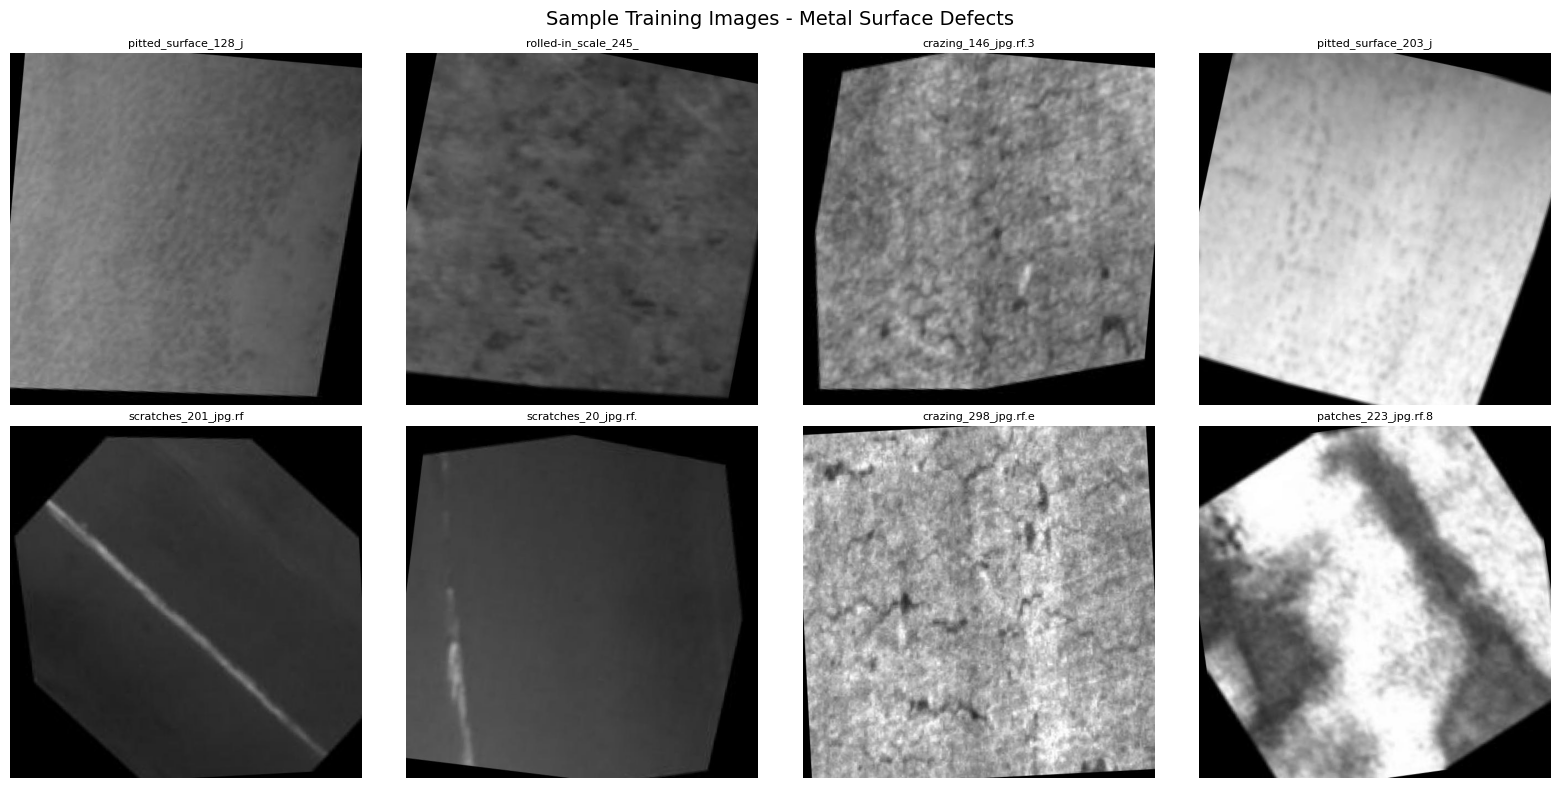

In [9]:
# Visualize some sample images
import matplotlib.pyplot as plt
import cv2
import random

train_img_dir = os.path.join(dataset.location, 'train', 'images')
sample_images = random.sample(os.listdir(train_img_dir), min(8, len(os.listdir(train_img_dir))))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img_name in zip(axes.flatten(), sample_images):
    img = cv2.imread(os.path.join(train_img_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_name[:20], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images - Metal Surface Defects', fontsize=14)
plt.tight_layout()
plt.show()

## Step 5: Train YOLOv8 Model

Model is auto-selected based on GPU VRAM (yolov8s for 6GB+, yolov8n for smaller).

Key training settings for high accuracy on metal defects:
- **100 epochs** with patience=20 early stopping
- **Heavy augmentation**: mosaic, vertical/horizontal flip, HSV shifts, scale jitter
- **Cosine LR schedule** for smoother convergence
- **close_mosaic=15**: disables mosaic in last 15 epochs for fine-tuning on clean images

Expected: **mAP50 > 0.75** (target: 80%+)

Training times:
- **Kaggle P100 / Colab T4** (yolov8s, batch=16): ~35-50 min
- **Local GTX 1650 Ti** (yolov8n, batch=8): ~45-60 min

In [10]:
from ultralytics import YOLO

print(f"Loading pretrained {MODEL_SIZE}...")
model = YOLO(MODEL_SIZE)

results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    name="metal_defect_detector",
    patience=PATIENCE,
    save=True,
    plots=True,
    device=DEVICE,
    workers=2 if ENV == "local" else 4,
    exist_ok=True,
    # augmentation tuned for metal surface textures
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    flipud=0.5,
    fliplr=0.5,
    mosaic=1.0,
    close_mosaic=15,
    scale=0.5,
    mixup=0.1,
    cos_lr=True,
)

print("\nTraining complete!")

Loading pretrained yolov8s.pt...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Defect-Detection-NEU-4/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=metal_defect_detector, nbs=64, nms=False, opset=None, opt

Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.


Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /kaggle/working/runs/detect/metal_defect_detector
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.


        1/5      4.21G      1.595      2.322      1.986         21        640: 100% ━━━━━━━━━━━━ 560/560 3.1it/s 3:02<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.4it/s 6.8s0.3s
                   all        729       1629      0.464      0.354       0.37      0.153

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        2/5      4.24G       1.47      1.893       1.88         14        640: 100% ━━━━━━━━━━━━ 560/560 3.2it/s 2:53<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.9it/s 5.9s0.3s
                   all        729       1629      0.506      0.478      0.467      0.203

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        3/5      4.28G      1.405      1.782       1.83         16        640: 100% ━━━━━━━━━━━━ 560/560 3.3it/s 2:51<0.2s
                 Class     Images

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


                   all        729       1629      0.655      0.675      0.737        0.4
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------        111        259      0.691      0.242      0.487      0.208
                     1        171        408        0.6      0.755      0.747      0.393
                     2        128        312      0.622      0.878      0.868      0.468
                     3        

## Step 6: Evaluate the Model

Check the model's performance on the validation set.

In [11]:
# Validate on the validation set
metrics = model.val()

print(f"\n=== Metal Defect Detection Results ===")
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 643.0±325.0 MB/s, size: 22.8 KB)
val: Scanning /kaggle/working/Defect-Detection-NEU-4/valid/labels.cache... 729 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 729/729 179.9Mit/s 0.0s
val: /kaggle/working/Defect-Detection-NEU-4/valid/images/crazing_120_jpg.rf.b7428443eac5b023fc45ff5dcefbb308.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 5.4it/s 8.5s0.1s


Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


                   all        729       1629      0.659      0.609      0.684       0.34
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------        111        259       0.78      0.082      0.395      0.135
                     1        171        408      0.539      0.725      0.713      0.335
                     2        128        312      0.672      0.808      0.821      0.417
                     3        


--- results.png ---


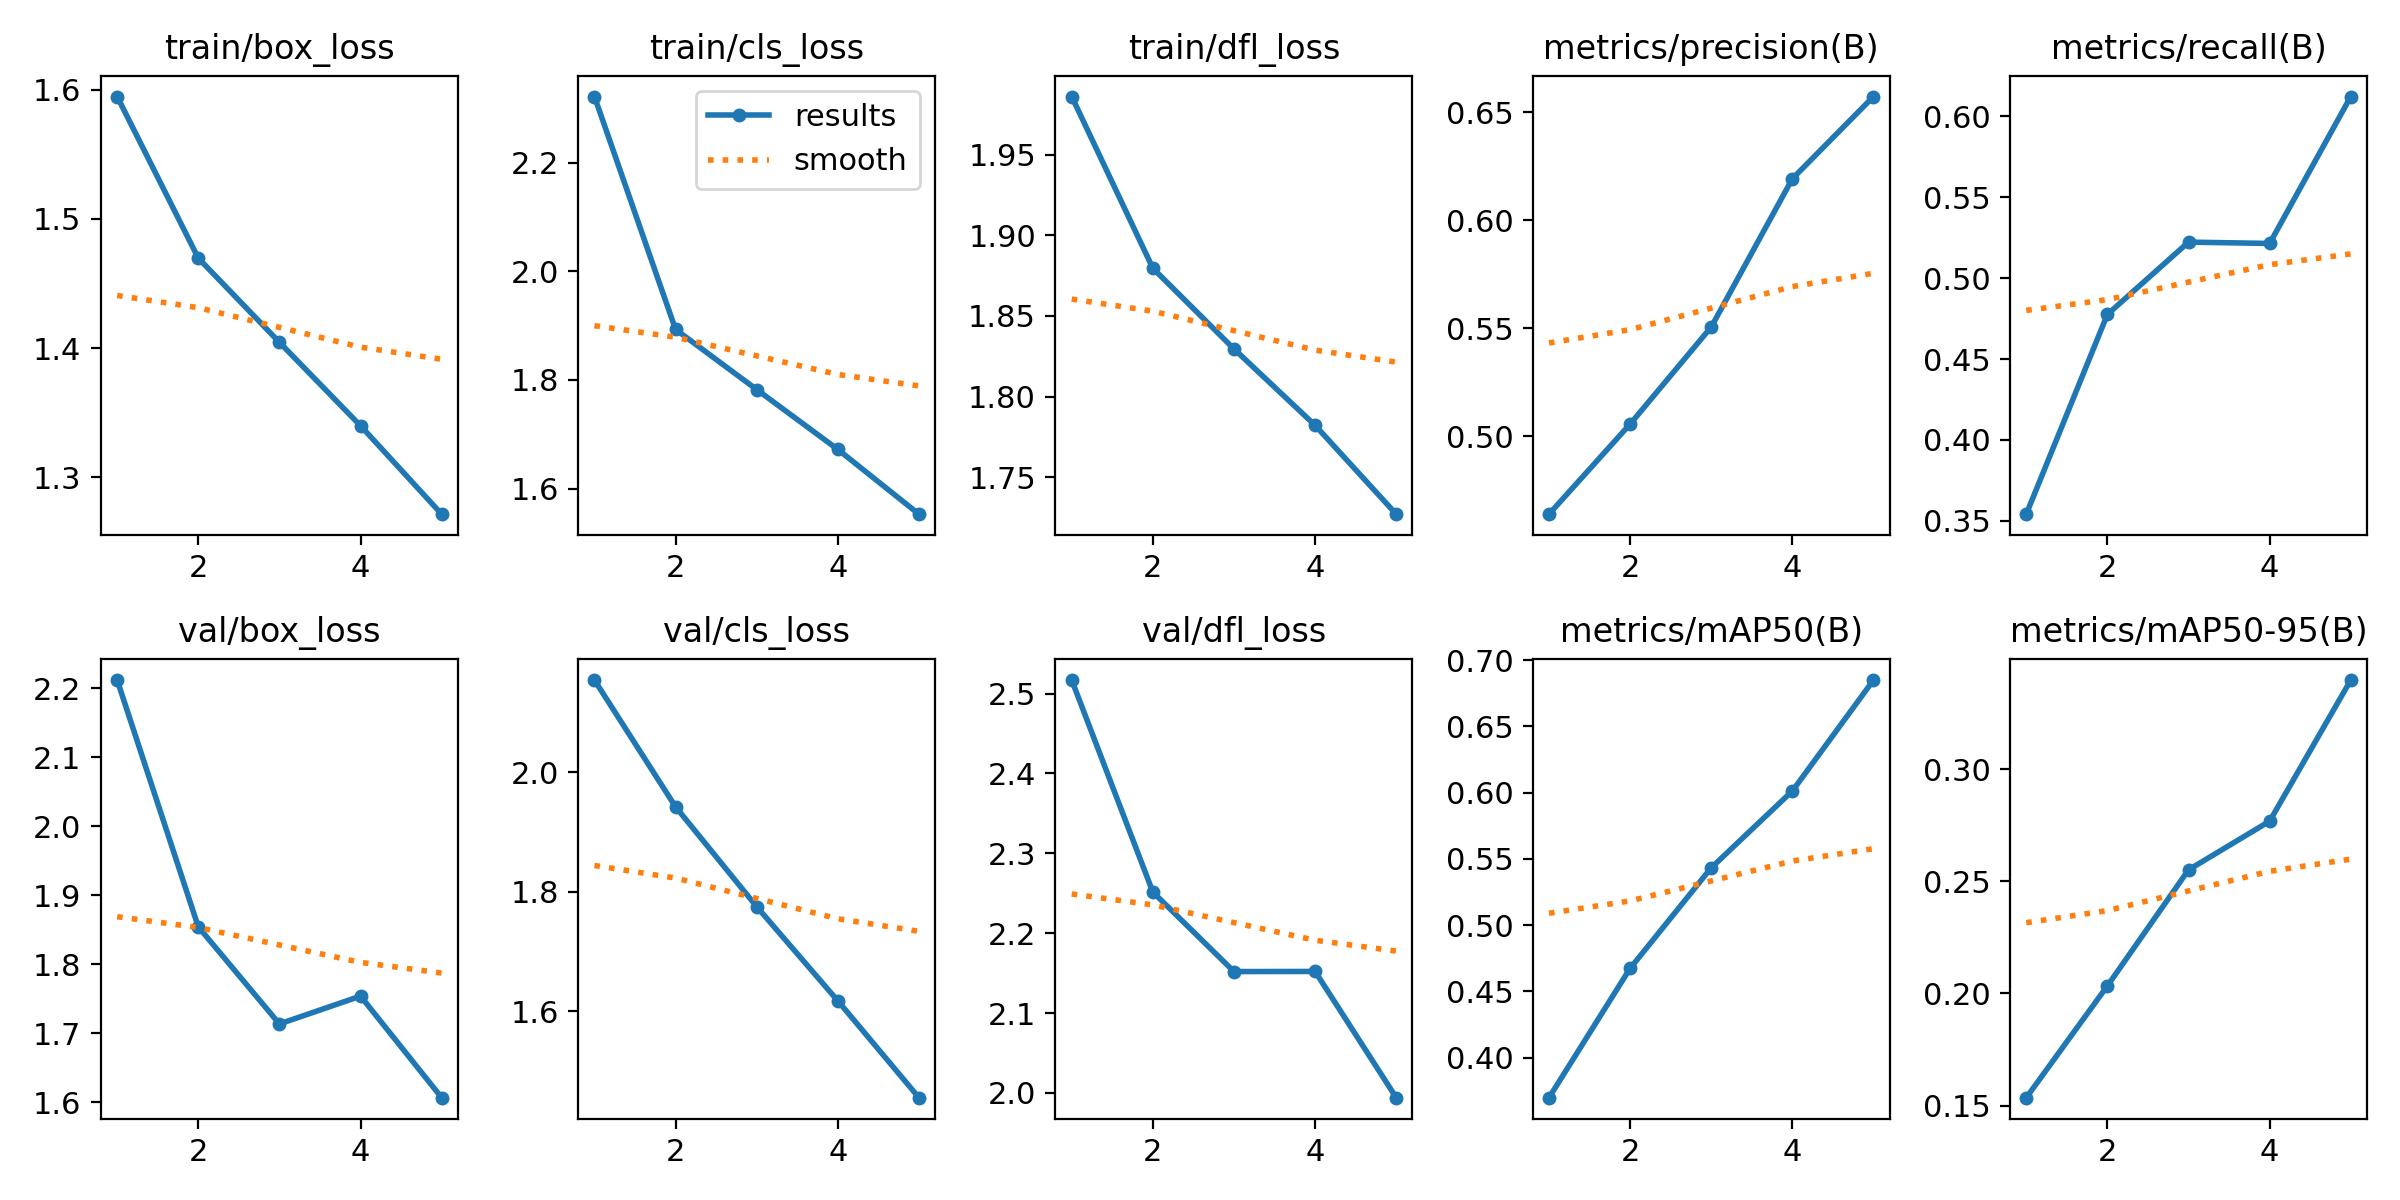


--- confusion_matrix.png ---


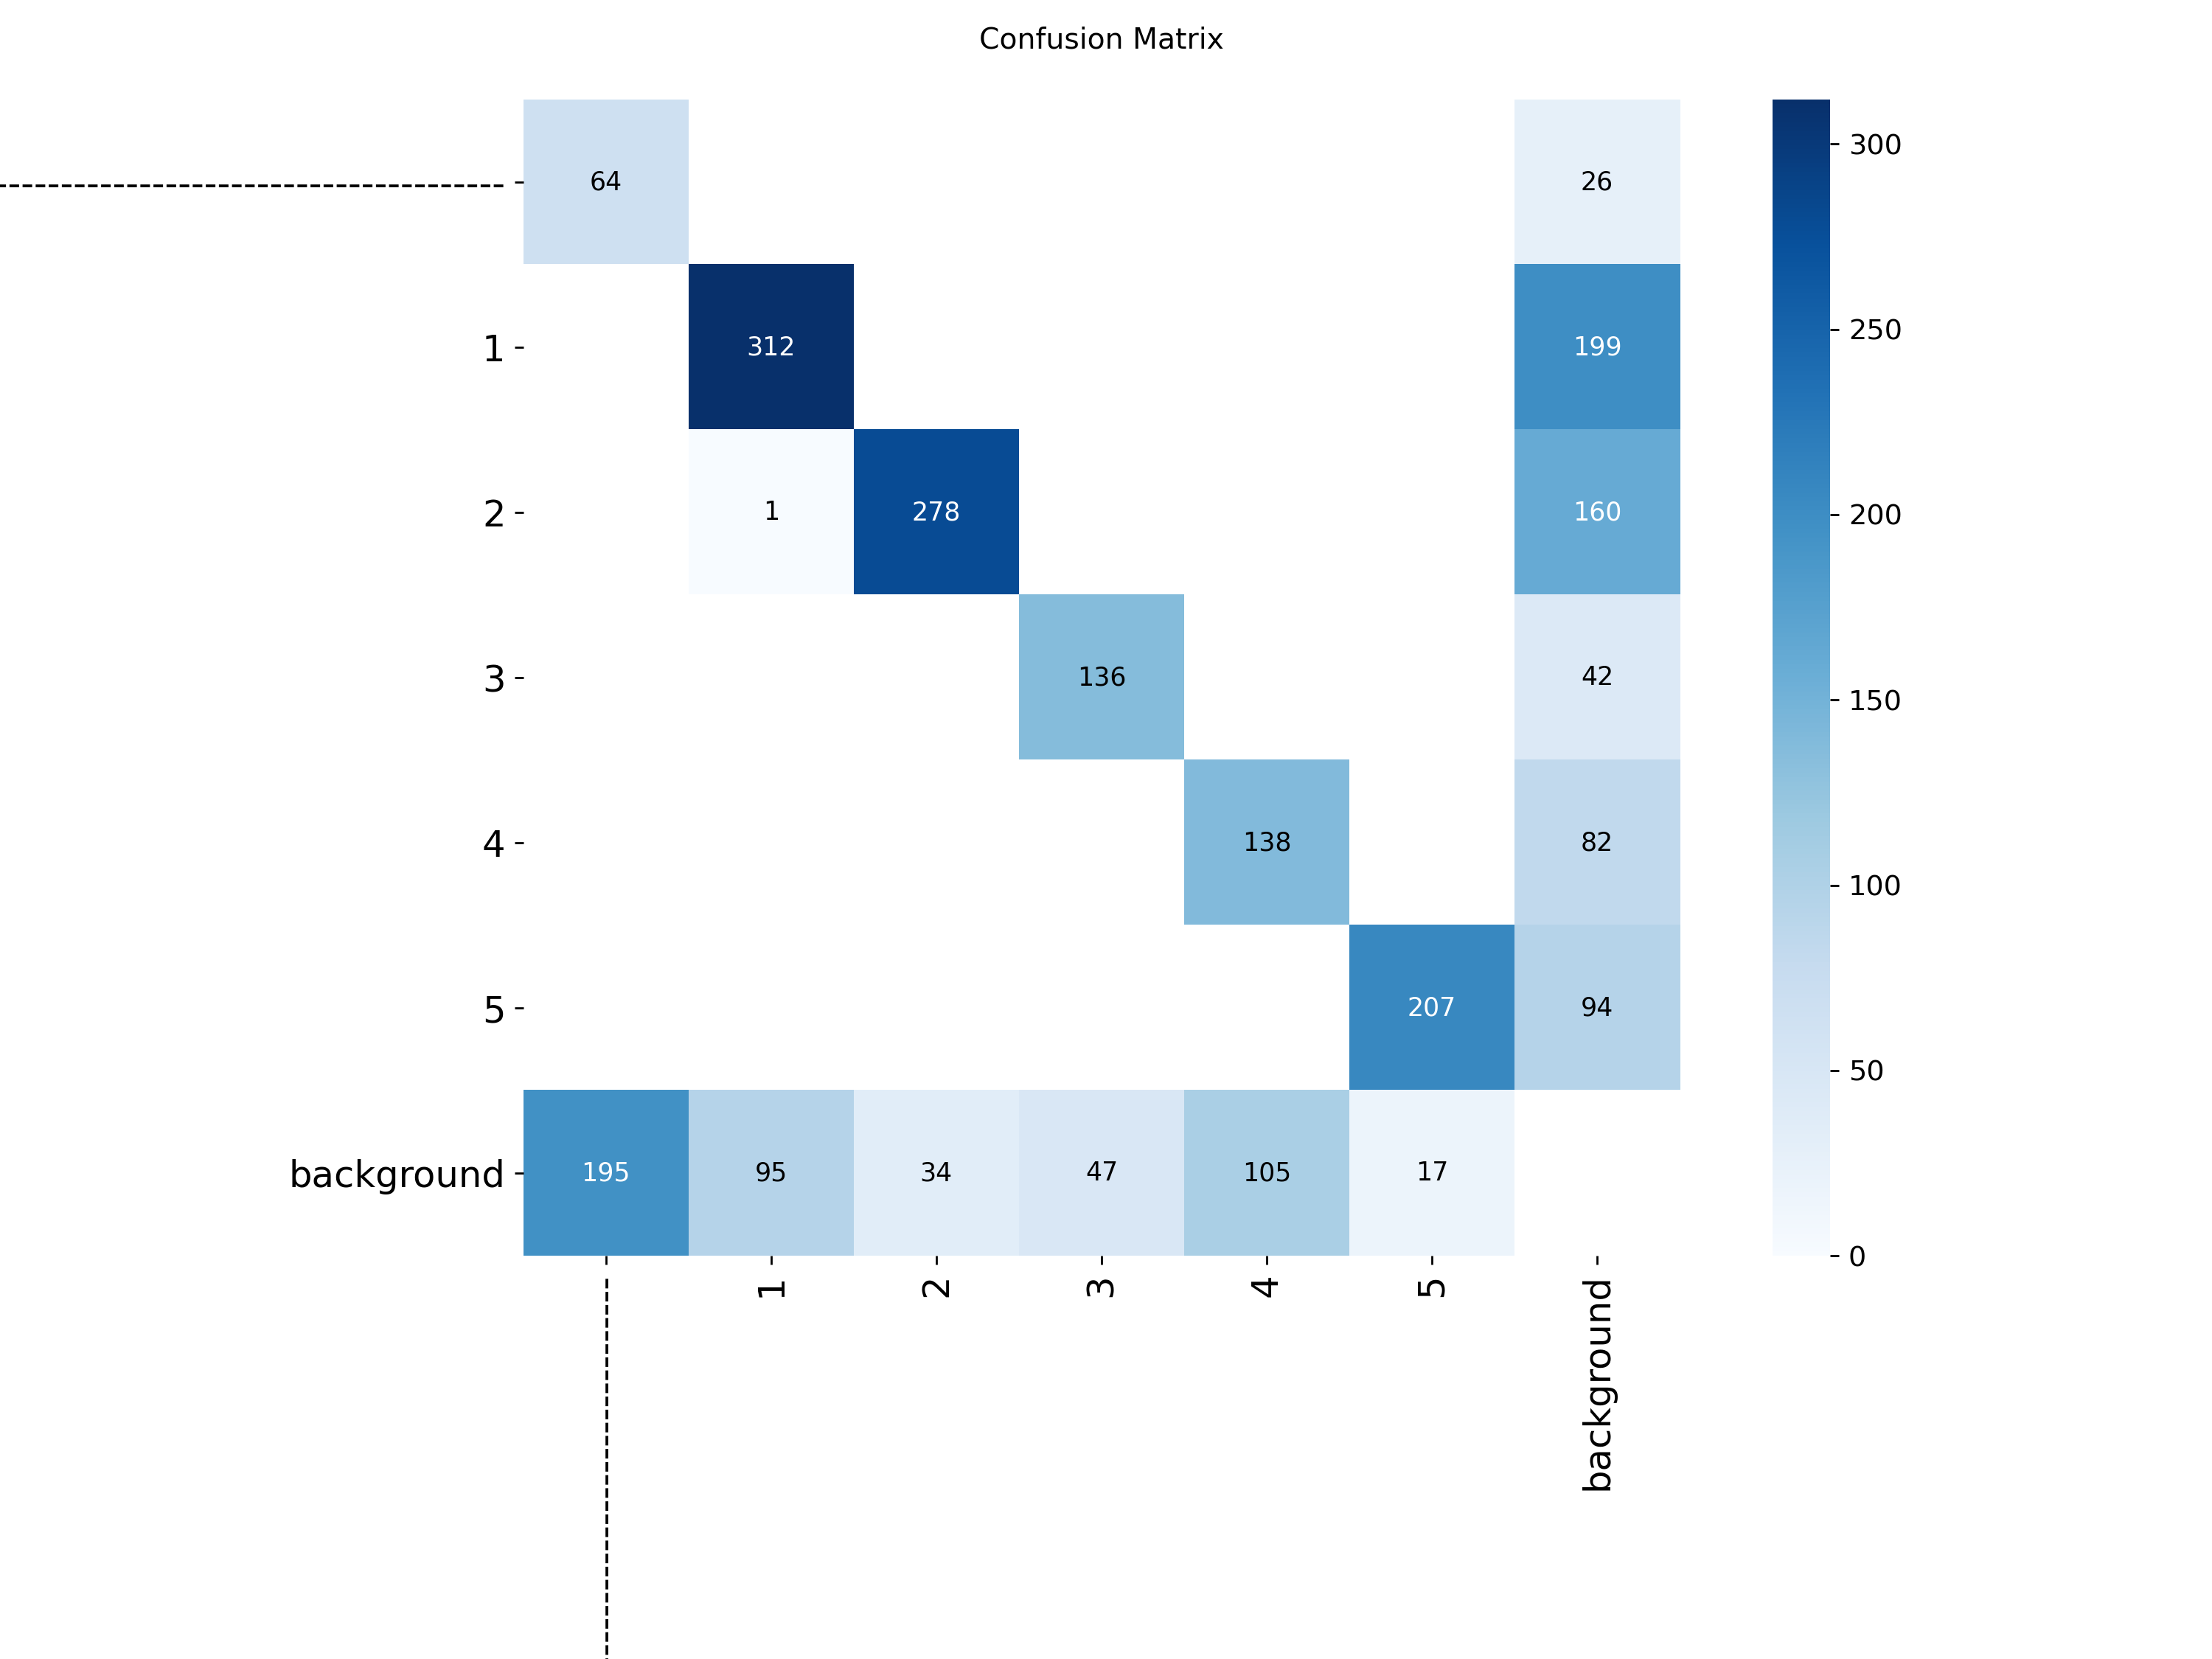

In [12]:
# Show training curves
from IPython.display import Image, display

# Display training results
results_dir = Path("runs/detect/metal_defect_detector")

for plot_name in ["results.png", "confusion_matrix.png", "val_batch0_pred.png"]:
    plot_path = results_dir / plot_name
    if plot_path.exists():
        print(f"\n--- {plot_name} ---")
        display(Image(filename=str(plot_path), width=800))

## Step 7: Test on Sample Images

Run inference on validation images to see the detections.

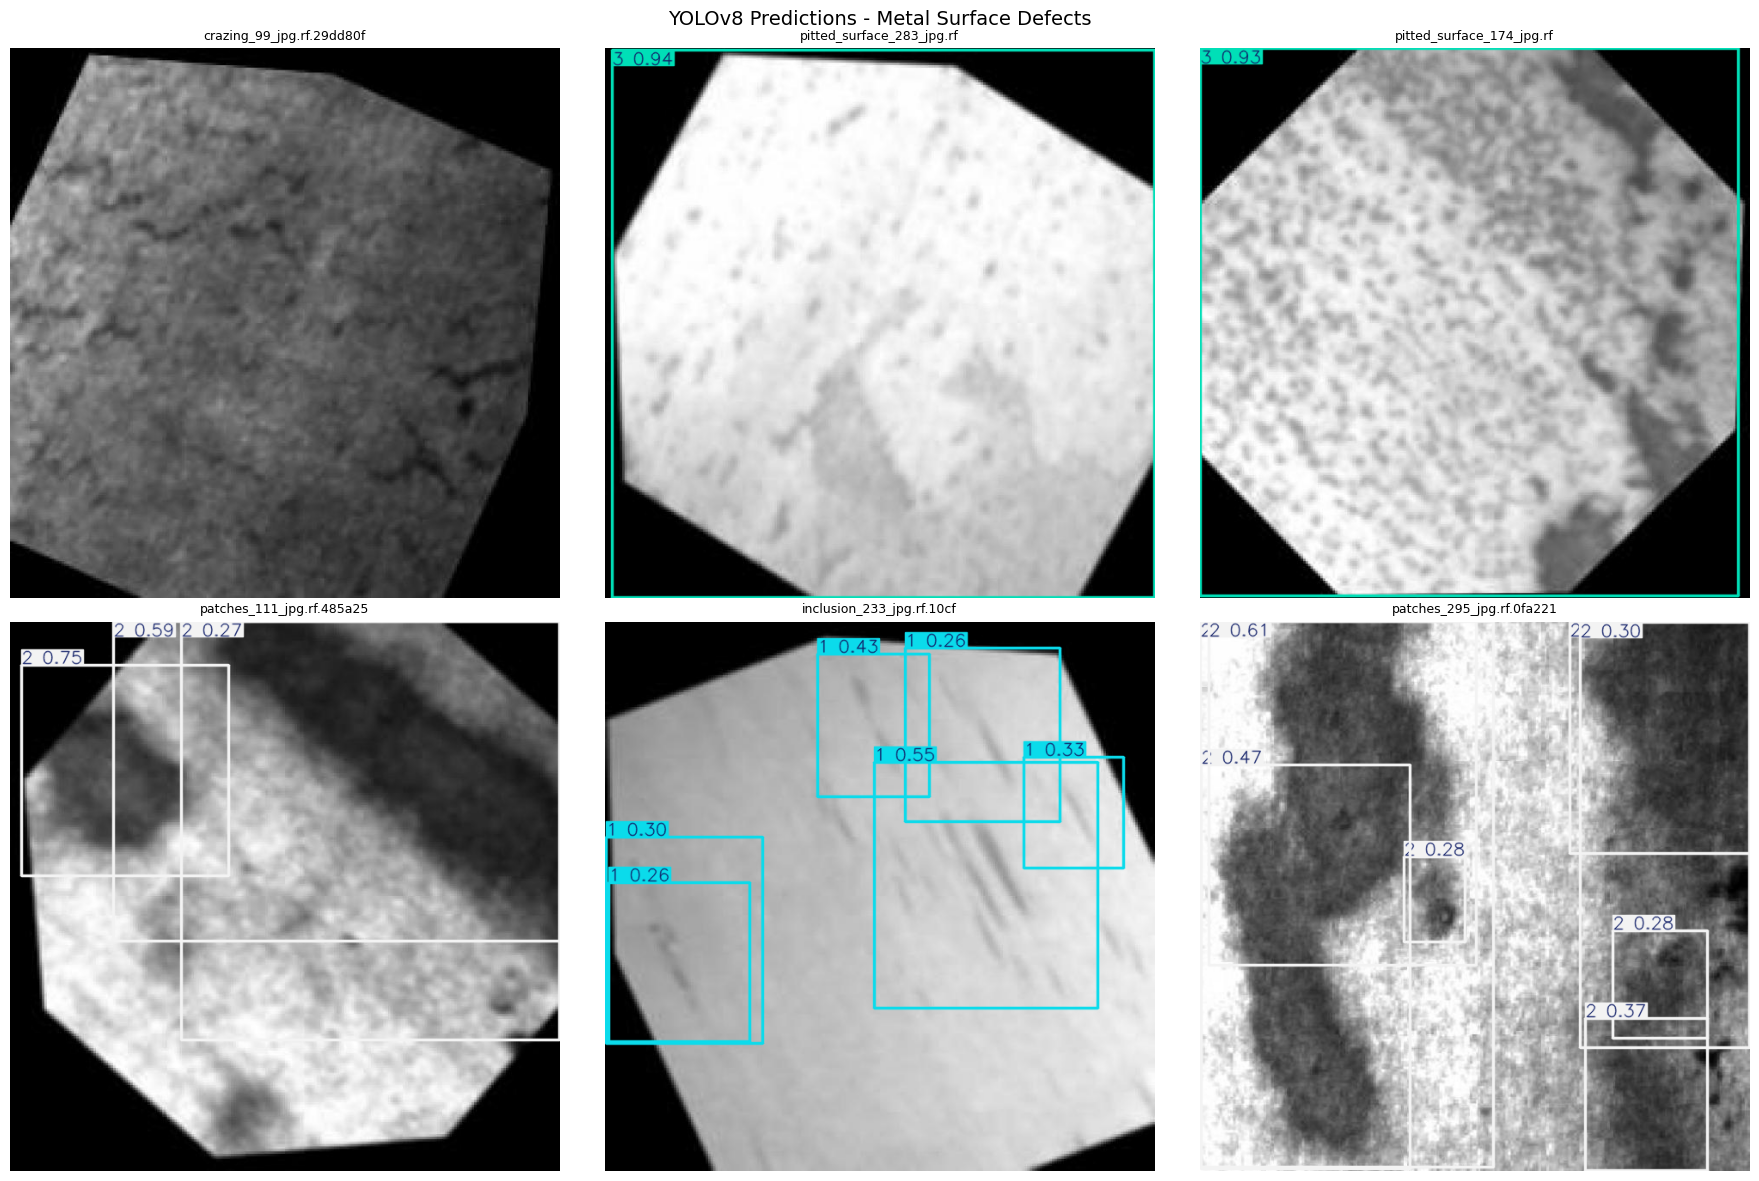

In [13]:
# Run inference on validation images
val_img_dir = os.path.join(dataset.location, 'valid', 'images')
if not os.path.exists(val_img_dir):
    val_img_dir = os.path.join(dataset.location, 'test', 'images')

val_images = os.listdir(val_img_dir)
sample_val = random.sample(val_images, min(6, len(val_images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, img_name in zip(axes.flatten(), sample_val):
    img_path = os.path.join(val_img_dir, img_name)
    results = model(img_path, conf=0.25, verbose=False)
    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.set_title(img_name[:25], fontsize=9)
    ax.axis('off')

plt.suptitle('YOLOv8 Predictions - Metal Surface Defects', fontsize=14)
plt.tight_layout()
plt.show()

## Step 8: Download Trained Weights

Download the `best.pt` file and place it in your local project at:
```
defect-vision/models/metal_yolo_best.pt
```

In [14]:
import shutil

best_weights = Path("runs/detect/metal_defect_detector/weights/best.pt")
if best_weights.exists():
    shutil.copy(best_weights, "metal_yolo_best.pt")
    print(f"Best weights saved to: metal_yolo_best.pt")
    print(f"File size: {best_weights.stat().st_size / 1e6:.1f} MB")
else:
    print(f"Could not find best.pt at {best_weights} - check the runs/ directory")

try:
    from google.colab import files
    files.download("metal_yolo_best.pt")
    print("\nDownload started! Save it to models/metal_yolo_best.pt")
except ImportError:
    if ENV == "kaggle":
        print("\nKaggle: find metal_yolo_best.pt in the Output tab")
    else:
        print("\nLocal: copy metal_yolo_best.pt to models/metal_yolo_best.pt")

Best weights saved to: metal_yolo_best.pt
File size: 22.5 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started! Save it to models/metal_yolo_best.pt
